# TSMAI ex5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from scipy.optimize import root_scalar

## Task 1.

### 1.1.

In [2]:
def find_all_roots(func,func_prime,args,search_range=(-10, 10), n_guesses=20, maxtol=1e-44):
    roots = set()
    for guess in np.linspace(search_range[0], search_range[1], n_guesses):
        try:
            result = root_scalar(
                func,
                fprime=func_prime,
                args=args,  # Tuple of (w_val, theta_val)
                x0=float(guess),
                method='newton'
            )
            if result.converged:
                roots.add(round(result.root, 8))
        except:
            continue
    if not result.converged:
        #print("#########################################################")
        x_guesses = np.linspace(search_range[0], search_range[1], n_guesses)
        for i, guess in enumerate(x_guesses):
            # Create a small bracket around the guess point
            left = max(search_range[0], guess - 1.0)  # 1.0 is bracket width
            right = min(search_range[1], guess + 1.0)
            
            # Verify sign change (required for brentq)
            f_left = func(left, *args)
            f_right = func(right, *args)
            
            if f_left * f_right < 0:  # Valid bracket
                try:
                    result = root_scalar(
                        func,
                        args=args,
                        bracket=[left, right],
                        method='brentq',
                        xtol=maxtol,
                        rtol=maxtol
                    )
                    if result.converged:
                        roots.add(round(result.root, 8))
                except:
                    continue
            
    return np.array(sorted(roots)), result.converged

In [3]:
class Map:
    def __init__(self, expr, params,order): # dynamic variables first
        self.params = params
        self.expr = expr
        self.lhs = expr.lhs
        self.func = sym.lambdify((params), self.lhs, modules=['numpy'])
        self.order_tupl = tuple(order.split())
        self.fp_vals = 'call FP method first'

        self.prime_expr = sym.diff(self.lhs, params[0])
        self.prime_expr_func = sym.lambdify((params[0], *self.params[1:]), self.prime_expr, modules=['numpy'])
        
        
    def __call__(self, param_vals: dict):

        param_val_tupl = tuple(param_vals[key] for key in self.order_tupl)

        return self.func(*param_val_tupl)
    
    def FP_num(self,initial_guess=0.0,default_params=None,plot=False,maxtol=1e-4):
        x = self.params[0]
        FP_eq = sym.Eq(x,self.lhs)

        
        g = FP_eq.lhs - FP_eq.rhs
        fp_func = sym.lambdify((x, *self.params[1:]), g, modules=['numpy'])
        prime_func = sym.lambdify((x, *self.params[1:]), sym.diff(g, x), modules=['numpy'])
        
        args = [default_params[key] for key in self.order_tupl]
        args = tuple(args[1:])

        roots, converged = find_all_roots(fp_func,prime_func,args,search_range=(-10, 10), n_guesses=20,maxtol=maxtol)

        # result = root_scalar(
        #     fp_func,
        #     fprime=prime_func,
        #     args=args,
        #     x0=float(initial_guess),
        #     method='newton'
        # )
        
        if converged:
            self.fp_vals = roots
            
            if plot:
                x_arr = np.linspace(-10,10,100)
                plt.plot(x_arr, self(default_params),label='map')
                plt.plot(x_arr,x_arr,label='bisectrix')
                plt.scatter(roots,roots,label='FP',color='r')
                plt.title('expression return plot')
                plt.xlabel('x_{n}')
                plt.ylabel('x_{n+1}')
                plt.legend()
                plt.show()

            return roots
        else:
            print('did not converge')
            print("here is a plot: ")
            x_arr = np.linspace(-10,10,100)
            plt.plot(x_arr, self(default_params))
            plt.plot(x_arr,x_arr)
            plt.title('expression return plot')
            plt.show()
    
    
    def FP(self,initial_guess=0.0,default_params=None,plot=False,maxtol=1e-4):
        x = self.params[0]
        FP_eq = sym.Eq(x,self.lhs)

        try:
            fp_solutions = sym.solve(FP_eq,x)

            if fp_solutions:
                other_params = [p for p in self.params if p != x]
                self.FP_func = sym.lambdify(other_params, fp_solutions[0], modules=['numpy'])

                return fp_solutions
        except Exception as e:
            print(f"Could not find fixed point symbolically: {e}")

            
            roots = self.FP_num(initial_guess=initial_guess,default_params=default_params,plot=plot,maxtol=maxtol)

            return roots
            
        
        return None

    
    def stability(self,param_vals,prints=False):
        if type(self.fp_vals) == str:
            print(self.fp_vals)

        param_val_tupl = tuple(param_vals[key] for key in self.order_tupl)
        #print(param_val_tupl)

        local_slope = self.prime_expr_func(*param_val_tupl)
        abs_slope = abs(local_slope)

        stab_list = []

        for i,slope in enumerate(abs_slope):
            if prints:
                if slope > 1: 
                    print(f'Unstable fp because local slope is |{local_slope}| > 1')
                elif slope < 1:
                    print(f'Stable because local slope is |{local_slope}| < 1')
                else: 
                    print(f'hihger order analysis needed because local slope is |{slope}| = 1')
            stab_list.append(slope < 1) # True stable, False unstable
        
        return local_slope, stab_list


Could not find fixed point symbolically: multiple generators [x, exp(x)]
No algorithms are implemented to solve equation x + (-theta - w/(1 + exp(-x)))


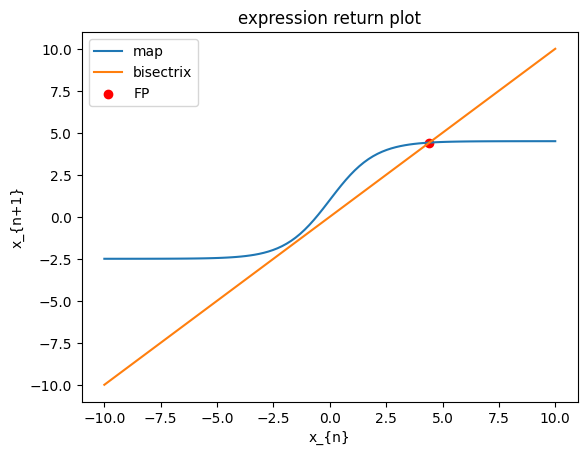

[4.41647135]
Stable because local slope is |[0.08253193]| < 1


In [4]:
x,w,theta = sym.symbols('x w theta')

expr = sym.Eq(w/(1+sym.exp(-x))+theta, 0) # lhs,rhs

# a = expr.free_symbols # set of symbols

MAP_task1 = Map(expr,[x,w,theta],'x w theta')
FPexpr = MAP_task1.FP(initial_guess=4.5,default_params={'x': np.linspace(-10,10,100),'w':7, 'theta':-2.5},plot=True)
print(MAP_task1.fp_vals)

FP_slope = MAP_task1.stability({'x':  MAP_task1.fp_vals,'w':7, 'theta':-2.5},prints=True)


### 1.2

In [5]:
from tqdm import tqdm

bifur_MAP = Map(expr,[x,w,theta],'x w theta')

theta_range = np.linspace(-10,0,1000)

FP_vals = []
theta_vals = []
colors = []

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    for theta_val in tqdm(theta_range):
        FPexpr = MAP_task1.FP_num(initial_guess=0,default_params={'x': np.linspace(-10,10,100),'w':7, 'theta':theta_val})
        

        if FPexpr is not None:
            theta = np.ones(len(FPexpr))*theta_val
            slope, stab_list = MAP_task1.stability({'x':  MAP_task1.fp_vals,'w':7, 'theta':theta_val})
            color = ['g' if stab else 'r' for stab in stab_list]
            FP_vals.extend(FPexpr)
            theta_vals.extend(theta)
            colors.extend(color)

100%|██████████| 1000/1000 [00:21<00:00, 47.44it/s]


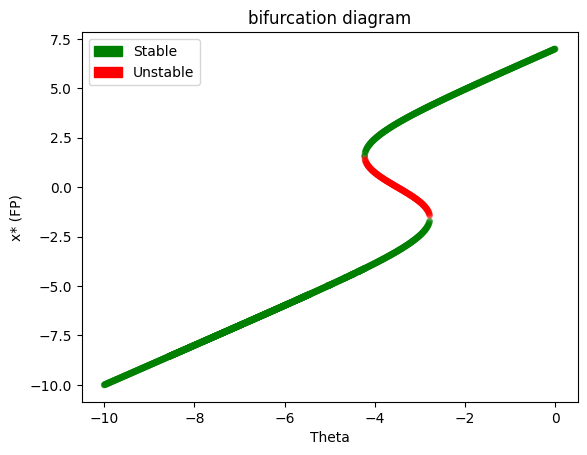

In [12]:
import matplotlib.patches as mpatches
plt.scatter(theta_vals,FP_vals,color=colors,alpha=0.5,s=15)
plt.title('bifurcation diagram')
plt.xlabel('Theta')
plt.ylabel('x* (FP)')
green_patch = mpatches.Patch(color='g', label='Stable')
red_patch = mpatches.Patch(color='r', label='Unstable')
plt.legend(handles=[green_patch, red_patch])
plt.show()

## Task 2

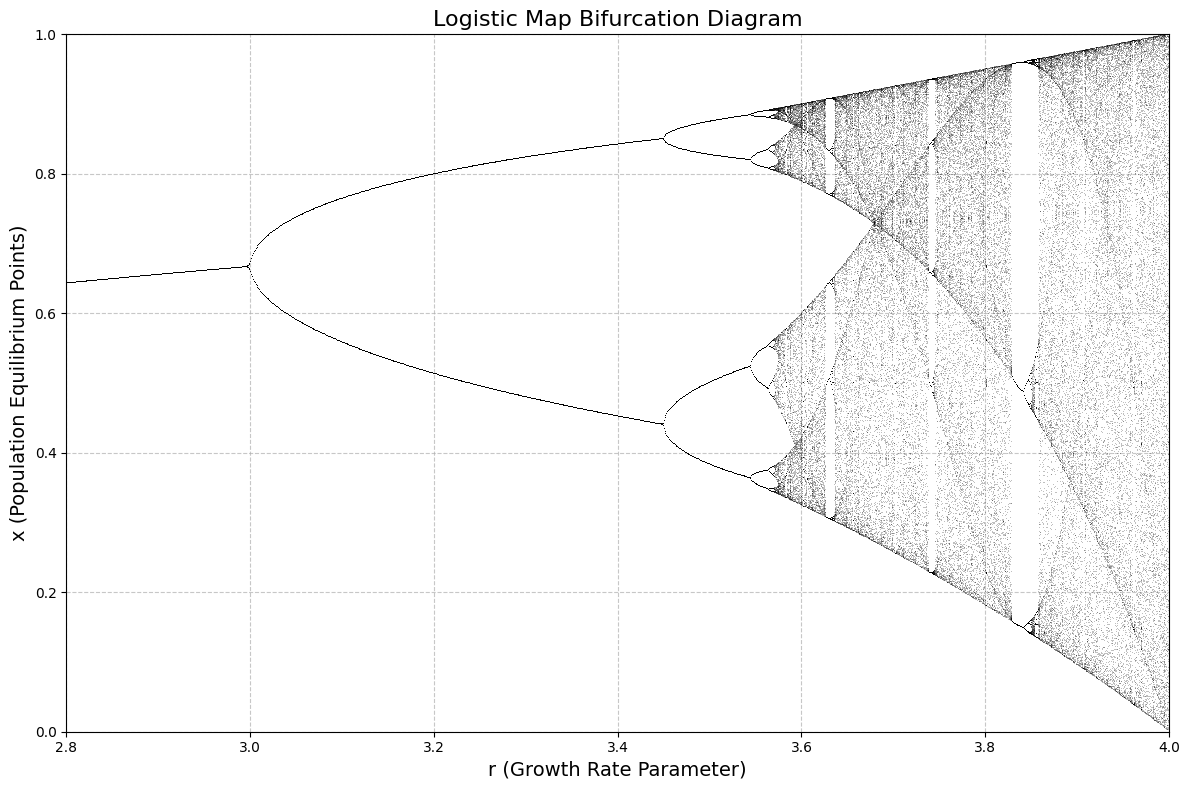

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
def plot_bifur_from_c(file,save=False):
    # Read the bifurcation data
    try:
        df = pd.read_csv(file)
    except FileNotFoundError:
        print("Error: bifurcation_data.csv not found. Run the C program first.")
        exit()

    # Plotting
    plt.figure(figsize=(12, 8))
    plt.plot(df['r'], df['x'], ',', alpha=0.25, color='black') # Use ',' for small markers

    plt.title("Logistic Map Bifurcation Diagram", fontsize=16)
    plt.xlabel("r (Growth Rate Parameter)", fontsize=14)
    plt.ylabel("x (Population Equilibrium Points)", fontsize=14)
    plt.xlim(df['r'].min(), df['r'].max())
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    if save:
        plt.savefig("bifurcation_diagram.png", dpi=300)
        print("Bifurcation diagram plotted and saved as bifurcation_diagram.png")
    plt.show()

    
plot_bifur_from_c("bifurcation_data.csv")

In [ ]:
plot_bifur_from_c("bifurcation_data.csv")